In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 5000

data = {
    'Customer_ID': np.arange(1001, 1001+n),
    'Age': np.random.randint(18, 65, n),
    'Gender': np.random.choice(['Male', 'Female'], n),
    'Region': np.random.choice(['North', 'South', 'East', 'West'], n),
    'Category': np.random.choice(['Electronics', 'Fashion', 'Home Appliances', 'Furniture', 'Sports'], n),
    'Sales': np.random.randint(500, 50000, n),
    'Promotion': np.random.choice([0,1], n),
    'Purchase_Mode': np.random.choice(['Online', 'Offline'], n),
    'Customer_Type': np.random.choice(['New', 'Returning'], n),
    'Month': np.random.choice([
        'Jan','Feb','Mar','Apr','May','Jun',
        'Jul','Aug','Sep','Oct','Nov','Dec'
    ], n)
}

df = pd.DataFrame(data)

df.to_csv('sales_customer_data.csv', index=False)

print("Dataset Created Successfully!")
print("Rows:", len(df))
print("Columns:", len(df.columns))
df.head()

Dataset Created Successfully!
Rows: 5000
Columns: 10


,Customer_ID,Age,Gender,Region,Category,Sales,Promotion,Purchase_Mode,Customer_Type,Month
0,1001,56,Male,North,Home Appliances,42680,1,Online,New,Dec
1,1002,46,Female,North,Sports,9333,0,Offline,New,Mar
2,1003,32,Male,South,Electronics,47403,0,Online,New,Feb
3,1004,60,Male,North,Furniture,33991,0,Online,New,Apr
4,1005,25,Male,North,Sports,29973,1,Online,Returning,Jul


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Customer_ID    5000 non-null   int64 
 1   Age            5000 non-null   int64 
 2   Gender         5000 non-null   object
 3   Region         5000 non-null   object
 4   Category       5000 non-null   object
 5   Sales          5000 non-null   int64 
 6   Promotion      5000 non-null   int64 
 7   Purchase_Mode  5000 non-null   object
 8   Customer_Type  5000 non-null   object
 9   Month          5000 non-null   object
dtypes: int64(4), object(6)
memory usage: 390.8+ KB
None
       Customer_ID         Age         Sales    Promotion
count  5000.000000  5000.00000   5000.000000  5000.000000
mean   3500.500000    41.16820  25166.011600     0.512600
std    1443.520003    13.53105  14317.234276     0.499891
min    1001.000000    18.00000    518.000000     0.000000
25%    2250.750000    29.00000

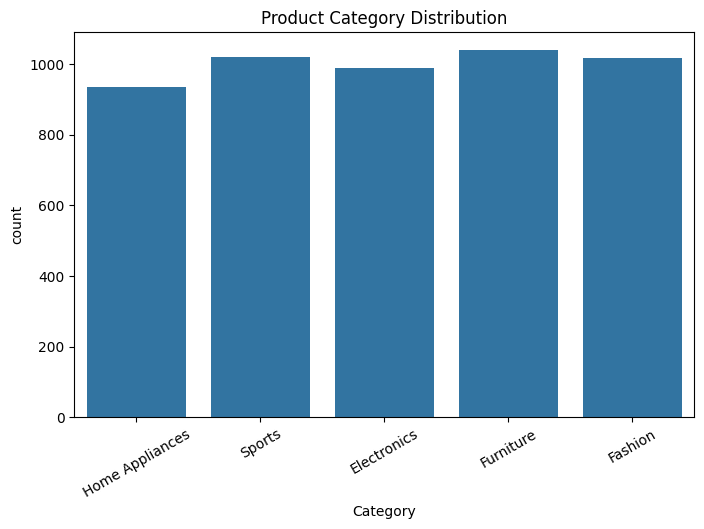

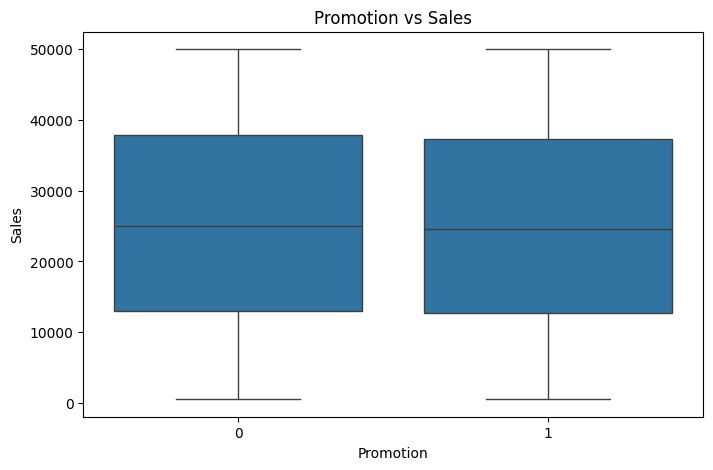

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('sales_customer_data.csv')

print(df.info())
print(df.describe())

plt.figure(figsize=(8,5))
sns.countplot(x='Category', data=df)
plt.title("Product Category Distribution")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x='Promotion', y='Sales', data=df)
plt.title("Promotion vs Sales")
plt.show()

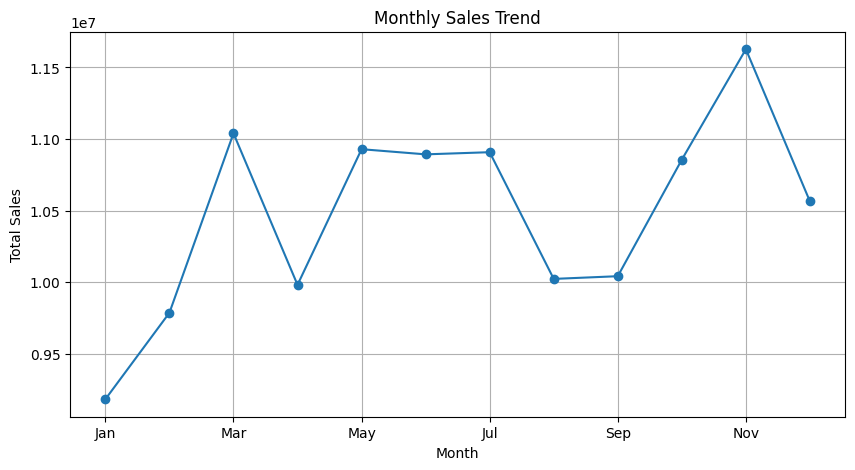

In [ ]:
monthly_sales = df.groupby('Month')['Sales'].sum()

monthly_sales = monthly_sales.reindex(
['Jan','Feb','Mar','Apr','May','Jun',
 'Jul','Aug','Sep','Oct','Nov','Dec']
)

plt.figure(figsize=(10,5))
monthly_sales.plot(marker='o')
plt.title("Monthly Sales Trend")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

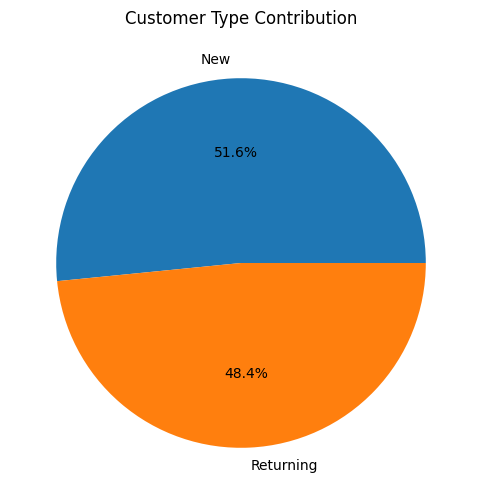

In [ ]:
customer_sales = df.groupby('Customer_Type')['Sales'].sum()

plt.figure(figsize=(6,6))
plt.pie(customer_sales,
        labels=customer_sales.index,
        autopct='%1.1f%%')
plt.title("Customer Type Contribution")
plt.show()

In [ ]:
from scipy.stats import ttest_ind

promo_sales = df[df['Promotion']==1]['Sales']
nonpromo_sales = df[df['Promotion']==0]['Sales']

t_stat, p_value = ttest_ind(promo_sales, nonpromo_sales)

print("T Statistic:", t_stat)
print("P Value:", p_value)

if p_value < 0.05:
    print("Reject H0")
    print("Promotions significantly affect sales")
else:
    print("Fail to Reject H0")
    print("No significant effect found")

T Statistic: -0.6503068707061379
P Value: 0.5155239101009637
Fail to Reject H0
No significant effect found


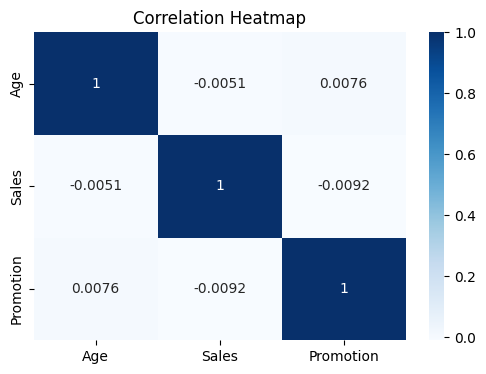

In [ ]:
numeric_df = df[['Age','Sales','Promotion']]

plt.figure(figsize=(6,4))
sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='Blues')

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
df.to_csv('cleaned_data.csv', index=False)

Index(['Customer_ID', 'Age', 'Gender', 'Region', 'Category', 'Sales',
       'Promotion', 'Purchase_Mode', 'Customer_Type', 'Month'],
      dtype='object')
   Customer_ID  Age  Gender Region         Category  Sales  Promotion  \
0         1001   56    Male  North  Home Appliances  42680          1   
1         1002   46  Female  North           Sports   9333          0   
2         1003   32    Male  South      Electronics  47403          0   
3         1004   60    Male  North        Furniture  33991          0   
4         1005   25    Male  North           Sports  29973          1   

  Purchase_Mode Customer_Type Month  
0        Online           New   Dec  
1       Offline           New   Mar  
2        Online           New   Feb  
3        Online           New   Apr  
4        Online     Returning   Jul  
Regional Sales Analysis:
  Region     Sales
1  North  32288702
3   West  31491455
2  South  31129142
0   East  30920759


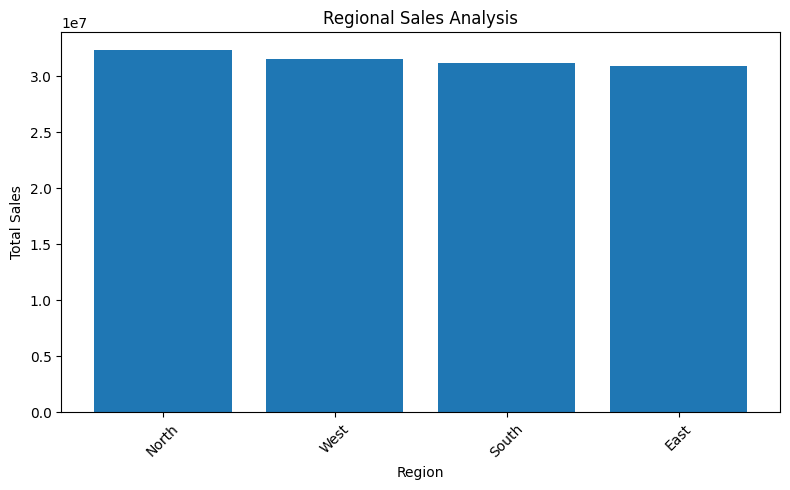

Best Performing Region: North
Total Sales: 32288702


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("cleaned_data.csv")

# Check columns
print(df.columns)
print(df.head())

# Regional Sales Analysis
regional_sales = df.groupby("Region")["Sales"].sum().reset_index()

# Sort highest to lowest
regional_sales = regional_sales.sort_values(by="Sales", ascending=False)

print("Regional Sales Analysis:")
print(regional_sales)

# Bar Chart
plt.figure(figsize=(8, 5))
plt.bar(regional_sales["Region"], regional_sales["Sales"])
plt.title("Regional Sales Analysis")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Best performing region
best_region = regional_sales.iloc[0]

print(f"Best Performing Region: {best_region['Region']}")
print(f"Total Sales: {best_region['Sales']}")

In [ ]:
import pandas as pd
from scipy.stats import ttest_ind

df = pd.read_csv("sales_customer_data.csv")

promo_sales = df[df["Promotion"] == 1]["Sales"]
nonpromo_sales = df[df["Promotion"] == 0]["Sales"]

t_stat, p_value = ttest_ind(promo_sales, nonpromo_sales)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

if p_value < 0.05:
    print("Reject H0")
    print("Promotions have a significant impact on sales.")
else:
    print("Fail to Reject H0")
    print("Promotions do not have a significant impact on sales.")

T-Statistic: -0.6503068707061379
P-Value: 0.5155239101009637
Fail to Reject H0
Promotions do not have a significant impact on sales.
